<a href="https://colab.research.google.com/github/saadetsenaeroglu/heart-attack-risk/blob/main/Sa%C4%9Fl%C4%B1kta_Yapay_Zeka_Varyantist.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [23]:
!pip install catboost

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 97.1/97.1 MB 9.8 MB/s eta 0:00:00


2.1 Veri Toplama
Verisetindeki veriler ClinGen ve ClinVar public veritabanlarından alınmış ve anonimleştirilmiştir.

TÜM KODLAR DÜZENLEME SONRASI:

2.1 Veri Toplama Verisetindeki veriler ClinGen ve ClinVar public veritabanlarından alınmış ve anonimleştirilmiştir.

In [3]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from scipy.stats import shapiro

# read_csv: CSV dosyasını okuyarak Pandas DataFrame (veri tablosu) formatına çevirir.
df = pd.read_csv('YARISMA_TRAIN_CFTR.csv')
random_durum = 42

2.2 Keşifsel Veri Analizi (EDA)

In [4]:
#print("Veriseti Boyutu:", df.shape)

# value_counts(): İlgili sütundaki verilerin frekansını (hangi değerden kaç tane olduğunu) sayar.
display(df.dtypes.value_counts().to_frame(name='Sütun Sayısı'))

display(df.head())
display(df.tail())
display(df.describe())

,Sütun Sayısı
float64,343
object,9
int64,1


,Variant_ID,AL_1,AL_2,AL_3,AL_4,AL_5,AL_6,AL_7,AL_8,AL_9,...,AL_334,EK_4,EK_5,EK_6,EK_7,EK_8,EK_9,AA_1,AA_2,Label
0,VAR_001979,NaN,NaN,NaN,NaN,NaN,NaN,0.001345,0.096892,1.242648e-08,...,1.0,0.996891,0.990927,0.985635,7.425321,0.678053,7.668385,L,P,1
1,VAR_001959,NaN,NaN,NaN,NaN,NaN,NaN,0.010535,0.000001,2.707313e-02,...,0.0,0.995255,1.000000,0.963307,6.682952,0.576330,7.871968,S,F,1
2,VAR_001788,NaN,NaN,NaN,NaN,NaN,NaN,0.000276,0.094085,2.461767e-02,...,1.0,1.000000,0.992648,0.987490,7.887457,0.605802,11.896000,G,E,1
3,VAR_001874,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,1.000000,0.964879,0.994672,1.491007,0.649775,0.954653,S,R,1
4,VAR_001775,NaN,NaN,NaN,NaN,NaN,NaN,0.006182,0.006907,4.454569e-09,...,1.0,0.991074,0.992799,0.981015,7.167948,0.662192,11.762793,W,C,1


,Variant_ID,AL_1,AL_2,AL_3,AL_4,AL_5,AL_6,AL_7,AL_8,AL_9,...,AL_334,EK_4,EK_5,EK_6,EK_7,EK_8,EK_9,AA_1,AA_2,Label
106,VAR_001934,NaN,NaN,NaN,NaN,NaN,NaN,0.005623,0.000550,0.000060,...,0.0,0.991002,0.639497,0.958080,7.426630,0.696964,7.589199,I,T,0
107,VAR_001798,NaN,NaN,NaN,NaN,NaN,NaN,0.000092,0.001397,0.023325,...,0.0,0.972268,0.570470,1.000000,3.723291,0.599779,5.621556,R,C,1
108,VAR_001912,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,0.0,0.968341,0.791487,1.000000,5.963446,0.640738,8.083601,I,S,0
109,VAR_001887,NaN,NaN,NaN,NaN,NaN,NaN,0.000003,0.011318,0.043873,...,1.0,0.983993,1.000000,0.977525,7.221406,0.632189,7.609308,Y,D,1
110,VAR_001956,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,1.0,0.830599,1.000000,0.951927,-0.035709,0.612260,0.658133,D,E,0


,AL_1,AL_2,AL_3,AL_4,AL_5,AL_6,AL_7,AL_8,AL_9,AL_10,...,AL_332,AL_333,AL_334,EK_4,EK_5,EK_6,EK_7,EK_8,EK_9,Label
count,15.000000,1.500000e+01,1.500000e+01,1.500000e+01,1.500000e+01,1.500000e+01,9.400000e+01,9.400000e+01,9.400000e+01,9.400000e+01,...,96.0,96.000000,96.000000,111.000000,111.000000,111.000000,111.000000,111.000000,111.000000,111.000000
mean,0.005241,5.204499e-02,1.586077e-02,2.191732e-03,7.223159e-03,2.168735e-02,5.050237e-03,3.059204e-02,9.362980e-03,3.291331e-03,...,1.0,0.468750,0.625000,0.973742,0.945476,0.958222,6.710045,0.634984,8.284521,0.810811
std,0.007401,4.273259e-02,2.639352e-02,4.326904e-03,1.655041e-02,3.008510e-02,1.414265e-02,4.183315e-02,1.678717e-02,8.176362e-03,...,0.0,0.501642,0.486664,0.109178,0.119166,0.169611,2.485614,0.116094,3.323848,0.393435
min,0.000180,4.333240e-07,1.089844e-19,6.744036e-12,5.713352e-21,3.153803e-10,9.966354e-08,4.685714e-14,2.477875e-27,7.555121e-23,...,1.0,0.000000,0.000000,0.023496,0.458217,0.000000,-0.035709,-0.133038,-1.186301,0.000000
25%,0.000540,1.004286e-02,1.265635e-04,2.829521e-07,4.499074e-04,1.198902e-03,9.138976e-06,8.345529e-06,2.251735e-05,1.610809e-08,...,1.0,0.000000,0.000000,0.983857,0.971484,0.981246,5.926941,0.609527,7.386621,1.000000
50%,0.001479,4.559165e-02,1.260152e-03,8.302969e-05,9.045203e-04,8.897813e-03,1.044576e-04,1.635882e-03,7.310017e-04,3.712968e-05,...,1.0,0.000000,1.000000,0.996891,0.992648,1.000000,7.414667,0.645952,8.099662,1.000000
75%,0.006340,9.696237e-02,2.350179e-02,2.209261e-03,4.092247e-03,2.990269e-02,1.662471e-03,8.520774e-02,1.194061e-02,1.748897e-03,...,1.0,1.000000,1.000000,1.000000,1.000000,1.000000,8.431110,0.681444,11.387971,1.000000
max,0.024678,1.086073e-01,7.256611e-02,1.648582e-02,6.358494e-02,9.148541e-02,8.242005e-02,1.002151e-01,9.045987e-02,4.905852e-02,...,1.0,1.000000,1.000000,1.000000,1.000000,1.000000,9.938000,0.756000,11.896000,1.000000


In [5]:
print("\n--- Eksik ve Benzersiz Değerler Özeti ---")

# nunique(): İlgili sütunda kaç farklı (benzersiz) değer olduğunu döndürür.
ozet_tablosu = pd.DataFrame({
    'Veri Tipi': df.dtypes,
    'Eksik Değer Sayısı': df.isnull().sum(),
    'Eksiklik Oranı (%)': (df.isnull().sum() / len(df) * 100).round(2),
    'Benzersiz Değer Sayısı': df.nunique()
})

# sort_values(): Tabloyu belirttiğimiz sütuna göre sıralar (ascending=False: büyükten küçüğe)
ozet_tablosu = ozet_tablosu.sort_values(by='Eksik Değer Sayısı', ascending=False)
display(ozet_tablosu)

# select_dtypes(): Sadece belirttiğimiz veri tipindeki (burada sayısal) sütunları filtreler.
sayisal_sutunlar = df.select_dtypes(include=[np.number]).columns.tolist()
korelasyon_matrisi = df[sayisal_sutunlar[:10]].corr()


--- Eksik ve Benzersiz Değerler Özeti ---


,Veri Tipi,Eksik Değer Sayısı,Eksiklik Oranı (%),Benzersiz Değer Sayısı
CAT_6,object,109,98.20,1
AL_33,float64,96,86.49,5
AL_29,float64,96,86.49,2
AL_30,float64,96,86.49,15
AL_27,float64,96,86.49,3
...,...,...,...,...
CAT_3,object,0,0.00,5
CAT_4,object,0,0.00,5
EK_2,float64,0,0.00,111
EK_1,float64,0,0.00,111


In [6]:
print("\n--- Eksik ve Benzersiz Değerler Özeti ---")

# nunique(): İlgili sütunda kaç farklı (benzersiz) değer olduğunu döndürür.
ozet_tablosu = pd.DataFrame({
    'Veri Tipi': df.dtypes,
    'Eksik Değer Sayısı': df.isnull().sum(),
    'Eksiklik Oranı (%)': (df.isnull().sum() / len(df) * 100).round(2),
    'Benzersiz Değer Sayısı': df.nunique()
})

# sort_values(): Tabloyu belirttiğimiz sütuna göre sıralar (ascending=False: büyükten küçüğe)
ozet_tablosu = ozet_tablosu.sort_values(by='Eksik Değer Sayısı', ascending=False)
display(ozet_tablosu)

# select_dtypes(): Sadece belirttiğimiz veri tipindeki (burada sayısal) sütunları filtreler.
sayisal_sutunlar = df.select_dtypes(include=[np.number]).columns.tolist()
korelasyon_matrisi = df[sayisal_sutunlar[:10]].corr()


--- Eksik ve Benzersiz Değerler Özeti ---


,Veri Tipi,Eksik Değer Sayısı,Eksiklik Oranı (%),Benzersiz Değer Sayısı
CAT_6,object,109,98.20,1
AL_33,float64,96,86.49,5
AL_29,float64,96,86.49,2
AL_30,float64,96,86.49,15
AL_27,float64,96,86.49,3
...,...,...,...,...
CAT_3,object,0,0.00,5
CAT_4,object,0,0.00,5
EK_2,float64,0,0.00,111
EK_1,float64,0,0.00,111


In [7]:
# Select only object columns and iterate through them
object_cols = df.select_dtypes(include=['object']).columns

for col in object_cols:
    print(f"\n[ COLUMN: {col} ]")
    print(f"Total Unique Values: {df[col].nunique()}")
    print("-" * 40)
    print(df[col].unique())
    print("=" * 50)


[ COLUMN: Variant_ID ]
Total Unique Values: 111
----------------------------------------
['VAR_001979' 'VAR_001959' 'VAR_001788' 'VAR_001874' 'VAR_001775'
 'VAR_001781' 'VAR_001918' 'VAR_001796' 'VAR_001961' 'VAR_001834'
 'VAR_001942' 'VAR_001841' 'VAR_001924' 'VAR_001875' 'VAR_001926'
 'VAR_001958' 'VAR_001953' 'VAR_001869' 'VAR_001833' 'VAR_001882'
 'VAR_001936' 'VAR_001880' 'VAR_001797' 'VAR_001976' 'VAR_001791'
 'VAR_001795' 'VAR_001824' 'VAR_001916' 'VAR_001771' 'VAR_001825'
 'VAR_001881' 'VAR_001846' 'VAR_001790' 'VAR_001968' 'VAR_001948'
 'VAR_001893' 'VAR_001844' 'VAR_001780' 'VAR_001847' 'VAR_001816'
 'VAR_001923' 'VAR_001842' 'VAR_001822' 'VAR_001892' 'VAR_001930'
 'VAR_001784' 'VAR_001951' 'VAR_001884' 'VAR_001839' 'VAR_001838'
 'VAR_001862' 'VAR_001803' 'VAR_001868' 'VAR_001876' 'VAR_001901'
 'VAR_001980' 'VAR_001857' 'VAR_001848' 'VAR_001782' 'VAR_001982'
 'VAR_001879' 'VAR_001886' 'VAR_001888' 'VAR_001815' 'VAR_001817'
 'VAR_001896' 'VAR_001889' 'VAR_001785' 'VAR_001964'

2.3 Eksik Değer Temizleme

In [8]:
sinir_deger = len(df) * 0.50

# dropna(thresh=...): Belirtilen eşik değer (thresh) kadar DOLU verisi olmayan sütunları siler.
#df.dropna(thresh=sinir_deger, axis=1, inplace=True)
print("Filtre Sonrası Kalan Sütun Sayısı:", df.shape[1])

# Varyansı sıfır olan (tek değerli) sütunları bulma
tek_degerli_sutunlar = []
for sutun in df.columns:
    if df[sutun].nunique() == 1:
        tek_degerli_sutunlar.append(sutun)

print(df.shape)
print(f"Silinecek tek değerli sütun sayısı: {len(tek_degerli_sutunlar)}")
df.drop(columns=tek_degerli_sutunlar, inplace=True)

df.drop(columns=['Variant_ID'], inplace=True)
print(f"Temizlik sonrası veri seti boyutu: {df.shape}")

Filtre Sonrası Kalan Sütun Sayısı: 353
(111, 353)
Silinecek tek değerli sütun sayısı: 70
Temizlik sonrası veri seti boyutu: (111, 282)


2.4 Aykırı Değer Analizi

In [9]:
tum_sayisal_sutunlar = df.select_dtypes(include=[np.number]).columns
sayisal_sutunlar_filtrelenmis = []

for sutun in tum_sayisal_sutunlar:
    if sutun != 'Label':
        sayisal_sutunlar_filtrelenmis.append(sutun)

normal_dagilanlar = []
carpik_dagilanlar = []

for sutun in sayisal_sutunlar_filtrelenmis:
    sutun_verisi = df[sutun].dropna()

    if len(sutun_verisi) > 3:
      unique_sayisi=sutun_verisi.nunique()

      if sutun_verisi.nunique() <= 1:
        print(f"{sutun} {unique_sayisi} sütunu sabit değerlerden oluştuğu için analiz dışı bırakıldı.")
        continue # Döngünün bir sonraki adımına geçer

        # shapiro(): Verinin normal dağılıma uyup uymadığını test eden istatistiksel fonksiyondur.
        istatistik, p_degeri = shapiro(sutun_verisi)
        if p_degeri > 0.05:
            normal_dagilanlar.append(sutun)
            ortalama = sutun_verisi.mean()
            standart_sapma = sutun_verisi.std()
            alt_sinir = ortalama - (3 * standart_sapma)
            ust_sinir = ortalama + (3 * standart_sapma)
        else:
            carpik_dagilanlar.append(sutun)
            # quantile(0.25): Verinin %25'lik çeyreklik (Q1) sınırını bulur.
            Q1 = sutun_verisi.quantile(0.25)
            Q3 = sutun_verisi.quantile(0.75)
            IQR = Q3 - Q1
            alt_sinir = Q1 - 1.5 * IQR
            ust_sinir = Q3 + 1.5 * IQR

        # Aykırı değerleri alt ve üst sınırlara eşitliyoruz (Baskılama / Capping)
        df.loc[(df[sutun] < alt_sinir), sutun] = alt_sinir
        df.loc[(df[sutun] > ust_sinir), sutun] = ust_sinir

print(f"{len(normal_dagilanlar)} sütuna Z-Score sınırlandırması uygulandı.")
print(f"{len(carpik_dagilanlar)} sütuna IQR sınırlandırması uygulandı.")

0 sütuna Z-Score sınırlandırması uygulandı.
0 sütuna IQR sınırlandırması uygulandı.


In [10]:
print(f"Doldurma öncesi toplam eksik değer: {df.isnull().sum().sum()}")

# Sayısal sütunların medyan (ortanca değer) ile doldurulması
sayisal_sutunlar_tum = df.select_dtypes(include=[np.number]).columns
for sutun in sayisal_sutunlar_tum:
    df[sutun] = df[sutun].fillna(df[sutun].median())

print(f"Sayısal doldurma sonrası eksik değer: {df.isnull().sum().sum()}")

# Kategorik sütunların mod (en çok tekrar eden) ile doldurulması
kategorik_sutunlar = df.select_dtypes(include=['object', 'category']).columns

for sutun in kategorik_sutunlar:
    # mode()[0]: Veride en çok tekrar eden değer birden fazla ise (beraberlik), ilk sıradakini alır.
    en_cok_tekrar_eden = df[sutun].mode()[0]
    df[sutun] = df[sutun].fillna(en_cok_tekrar_eden)

print(f"Kategorik doldurma sonrası eksik değer: {df.isnull().sum().sum()}")

Doldurma öncesi toplam eksik değer: 9688
Sayısal doldurma sonrası eksik değer: 53
Kategorik doldurma sonrası eksik değer: 0


Popülasyon Verisi Sınıflandırma

In [11]:
# str.contains(): Metnin içinde belirtilen kelime geçiyorsa True, geçmiyorsa False döner.
# na=False parametresi, boş (NaN) satırlarda kodun hata vermesini engeller.
df=df.copy()
df['Pop_NFE'] = df['CAT_1'].str.contains('NFE', na=False).astype(int)
df['Pop_FIN'] = df['CAT_1'].str.contains('FIN', na=False).astype(int)
df['Pop_AFR'] = df['CAT_1'].str.contains('AFR', na=False).astype(int)
df['Pop_EAS'] = df['CAT_1'].str.contains('EAS', na=False).astype(int)
df['Pop_SAS'] = df['CAT_1'].str.contains('SAS', na=False).astype(int)
df['Pop_ASJ'] = df['CAT_1'].str.contains('ASJ', na=False).astype(int)
df['Pop_AMR'] = df['CAT_1'].str.contains('AMR', na=False).astype(int)
df['Pop_MID'] = df['CAT_1'].str.contains('MID', na=False).astype(int)

# DİKKAT: CAT_1 sütununu burada SİLMİYORUZ çünkü en alttaki hata analizlerinde lazım olacak!
df=df.copy()
# Analiz edilecek ilk 3 sayısal sütunu dinamik olarak (isimlerine bakılmaksızın) çekiyoruz
tum_sayisal_sutunlar = df.select_dtypes(include=[np.number]).columns
analiz_edilecek_sayisallar = []

for sutun in tum_sayisal_sutunlar:
    if sutun != 'Label' and not sutun.startswith('Pop_'):
        analiz_edilecek_sayisallar.append(sutun)

f1 = analiz_edilecek_sayisallar[0]
f2 = analiz_edilecek_sayisallar[1]
f3 = analiz_edilecek_sayisallar[2]

populasyon_sutunlar = ['Pop_NFE', 'Pop_FIN', 'Pop_AFR', 'Pop_EAS', 'Pop_SAS', 'Pop_ASJ', 'Pop_AMR', 'Pop_MID']
print(f"Popülasyon özellikleri eklendi. Yeni Veri Boyutu: {df.shape}")

Popülasyon özellikleri eklendi. Yeni Veri Boyutu: (111, 290)


2.7 Makine Öğrenmesi Modeli - Veri Hazırlığı ve Bölme

In [12]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler, OrdinalEncoder

# NOT: Hata analizinde kullanacağımız 'CAT_1' sütununu modele GİRMEMESİ için burada X içinden çıkarıyoruz
X = df.drop(columns=['Label', 'CAT_1'])

kategorik_sutunlar = []
# Kategorik verilerin etiket kodlaması (Label Encoding) ile sayısallaştırılması
for sutun in X.select_dtypes(include=['object', 'category']).columns:
    le = LabelEncoder()
    # fit_transform(): Modeli önce veriye uydurur (fit), ardından metinleri sayılara dönüştürür (transform).
    X[sutun] = le.fit_transform(X[sutun].astype(str))
    kategorik_sutunlar.append(sutun)


#encoder = OrdinalEncoder()
#X[kategorik_sutunlar] = encoder.fit_transform(X[kategorik_sutunlar])

from sklearn.ensemble import RandomForestClassifier
from sklearn.experimental import enable_iterative_imputer
from sklearn.impute import IterativeImputer

#kategorik_sütunlar = list(X.select_dtypes(include=("object")).columns)[1:]
#encoder = OrdinalEncoder()
#X[kategorik_sütunlar] = encoder.fit_transform(X[kategorik_sütunlar])
imputer = IterativeImputer(
    estimator=RandomForestClassifier(n_estimators=100, n_jobs=7),
    max_iter=100,
    random_state=random_durum,
)
dolu_veri = imputer.fit_transform(X[kategorik_sutunlar])
X[kategorik_sutunlar] = dolu_veri

X[kategorik_sutunlar].info()

y = df['Label']

# Eğitim ve test setlerinin ayrıştırılması (%20 Test)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=random_durum)

# Özellik ölçeklendirme standardizasyonu (StandardScaler)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
# transform(): Test verisine fit uygulanmaz, sadece eğitim verisinde öğrenilen oranlar uygulanır. (Veri sızıntısını önler)
X_test_scaled = scaler.transform(X_test)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 111 entries, 0 to 110
Data columns (total 6 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   CAT_2   111 non-null    float64
 1   CAT_3   111 non-null    float64
 2   CAT_4   111 non-null    float64
 3   CAT_5   111 non-null    float64
 4   AA_1    111 non-null    float64
 5   AA_2    111 non-null    float64
dtypes: float64(6)
memory usage: 5.3 KB


MODELLEME (parametre ayarlaması)

In [13]:
from sklearn.model_selection import GridSearchCV
from sklearn.ensemble import RandomForestClassifier
param_grid = {
    'max_features': ['sqrt', 'log2', 0.3, 0.7]
}

# Modeli ve Grid Search nesnesini oluştur
rf = RandomForestClassifier(random_state=42)

# scoring='f1' diyerek en iyi modeli F1-score'a göre seçmesini sağlıyoruz
grid_search = GridSearchCV(
    estimator=rf,
    param_grid=param_grid,
    cv=5,
    scoring='f1',
    n_jobs=-1
)

grid_search.fit(X_train_scaled, y_train)

print(f"En iyi max_features: {grid_search.best_params_['max_features']}")
print(f"En iyi F1-Score: {grid_search.best_score_:.4f}")

en_iyi_model = grid_search.best_estimator_
y_pred = en_iyi_model.predict(X_test_scaled)

En iyi max_features: sqrt
En iyi F1-Score: 0.9048


In [14]:
from sklearn.model_selection import GridSearchCV
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix

# 1. Denemek istediğin değer havuzunu (grid) belirle
# (Çok fazla değer yazarsan n_estimators=800 olduğu için işlem uzun sürebilir)
param_grid = {
    'min_samples_split': [2, 5, 10, 15],  # Bir düğümü bölmek için gereken min örnek
    'min_samples_leaf': [1, 2, 4, 6]      # Bir yaprakta kalması gereken min örnek
}

# 2. Temel modelini tanımla (Senin n_estimators ve random_state değerlerinle)
base_rf = RandomForestClassifier(n_estimators=40, random_state=random_durum)

# 3. GridSearchCV nesnesini oluştur
# f1 skorunu maksimum yapmaya çalışıyoruz (İstersen 'accuracy' veya 'recall' da yapabilirsin)
grid_search = GridSearchCV(
    estimator=base_rf,
    param_grid=param_grid,
    cv=5,                # 5-katlı çapraz doğrulama (Cross-Validation)
    scoring='f1',        # Optimize etmek istediğin metrik
    n_jobs=-1,           # Bilgisayarın tüm işlemci çekirdeklerini kullanarak hızlandırır
    verbose=1            # Ekranda sürecin ilerlemesini gösterir
)

# 4. Aramayı başlat (Eğitim verileriyle)
print("En verimli parametre kombinasyonu aranıyor...")
grid_search.fit(X_train_scaled, y_train)

# 5. En iyi sonuçları ekrana yazdır
print("\n" + "="*40)
print("Maksimum Verim Sağlayan Parametreler:", grid_search.best_params_)
print(f"Çapraz Doğrulama (CV) F1 Skoru: {grid_search.best_score_:.4f}")
print("="*40)

# 6. En iyi modeli otomatik olarak çek ve test verisinde dene
en_iyi_rf_model = grid_search.best_estimator_
y_pred_en_iyi = en_iyi_rf_model.predict(X_test_scaled)

# Yeni modelin sonuçlarını gör
print("\n--- Yeni Optimize Edilmiş Model Sonuçları ---")
print(classification_report(y_test, y_pred_en_iyi))

En verimli parametre kombinasyonu aranıyor...
Fitting 5 folds for each of 16 candidates, totalling 80 fits

Maksimum Verim Sağlayan Parametreler: {'min_samples_leaf': 4, 'min_samples_split': 2}
Çapraz Doğrulama (CV) F1 Skoru: 0.8931

--- Yeni Optimize Edilmiş Model Sonuçları ---
              precision    recall  f1-score   support

           0       1.00      0.25      0.40         4
           1       0.86      1.00      0.93        19

    accuracy                           0.87        23
   macro avg       0.93      0.62      0.66        23
weighted avg       0.89      0.87      0.84        23



In [15]:
from sklearn.preprocessing import MinMaxScaler

min_max_scaler = MinMaxScaler()
X_train_scaled = min_max_scaler.fit_transform(X_train)
X_test_scaled = min_max_scaler.transform(X_test)

Model kuruması

In [16]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix
from sklearn.preprocessing import RobustScaler

#1. Veri Ölçeklendirme (Scaling)
robust_scaler = RobustScaler()
X_train_scaled = robust_scaler.fit_transform(X_train)
X_test_scaled = robust_scaler.transform(X_test)

#2. Modelin Kurulması ve Eğitilmesi
rf_model = RandomForestClassifier( random_state=random_durum,
                                  n_estimators=800,
                                  max_features='sqrt',
                                  min_samples_leaf=4,
                                  min_samples_split=2,
                                  n_jobs=1 ,# Bilgisayarın tüm işlemci çekirdeklerini kullanarak hızlandırır
                                  verbose=1 )

#Model tahmin yapmadan önce mutlaka eğitilmelidir (fit).
rf_model.fit(X_train_scaled, y_train)

#3. Standart Eşik Değeri (0.50) ile Model Sonuçları
y_pred_standart = rf_model.predict(X_test_scaled)

print("\n--- Standart Eşik (0.50) ile Random Forest Sonuçları ---")
print(f"Accuracy (Doğruluk): {accuracy_score(y_test, y_pred_standart):.4f}")
print(f"Precision (Kesinlik): {precision_score(y_test, y_pred_standart, zero_division=0):.4f}")
print(f"Recall (Duyarlılık): {recall_score(y_test, y_pred_standart, zero_division=0):.4f}")
print(f"F1-Score: {f1_score(y_test, y_pred_standart, zero_division=0):.4f}")
print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred_standart))

#4. Manuel Eşik Değeri (0.44) ile Model Sonuçları
manuel_esik_degeri = 0.48

#Pozitif sınıfa (1) ait olasılık skorlarını alıyoruz
y_scores = rf_model.predict_proba(X_test_scaled)[:, 1]

#Olasılık, belirlediğin eşikten (0.44) büyükse 1, küçükse 0 olur
manuel_tahminler = (y_scores >= manuel_esik_degeri).astype(int)

print(f"\n--- Manuel Eşik ({manuel_esik_degeri}) ile Sonuçlar ---")
print(f"Accuracy (Doğruluk): {accuracy_score(y_test, manuel_tahminler):.4f}")
print(f"Precision (Kesinlik): {precision_score(y_test, manuel_tahminler, zero_division=0):.4f}")
print(f"Recall (Duyarlılık): {recall_score(y_test, manuel_tahminler, zero_division=0):.4f}")
print(f"F1-Score: {f1_score(y_test, manuel_tahminler, zero_division=0):.4f}")
print("Confusion Matrix:\n", confusion_matrix(y_test, manuel_tahminler))

[Parallel(n_jobs=1)]: Done  49 tasks      | elapsed:    0.1s
[Parallel(n_jobs=1)]: Done 199 tasks      | elapsed:    0.3s
[Parallel(n_jobs=1)]: Done 449 tasks      | elapsed:    0.6s



--- Standart Eşik (0.50) ile Random Forest Sonuçları ---
Accuracy (Doğruluk): 0.8696
Precision (Kesinlik): 0.8636
Recall (Duyarlılık): 1.0000
F1-Score: 0.9268
Confusion Matrix:
 [[ 1  3]
 [ 0 19]]

--- Manuel Eşik (0.48) ile Sonuçlar ---
Accuracy (Doğruluk): 0.8696
Precision (Kesinlik): 0.8636
Recall (Duyarlılık): 1.0000
F1-Score: 0.9268
Confusion Matrix:
 [[ 1  3]
 [ 0 19]]


[Parallel(n_jobs=1)]: Done 799 tasks      | elapsed:    1.0s
[Parallel(n_jobs=1)]: Done 800 out of 800 | elapsed:    1.1s finished
[Parallel(n_jobs=1)]: Done  49 tasks      | elapsed:    0.0s
[Parallel(n_jobs=1)]: Done 199 tasks      | elapsed:    0.0s
[Parallel(n_jobs=1)]: Done 449 tasks      | elapsed:    0.0s
[Parallel(n_jobs=1)]: Done 799 tasks      | elapsed:    0.1s
[Parallel(n_jobs=1)]: Done 800 out of 800 | elapsed:    0.1s finished
[Parallel(n_jobs=1)]: Done  49 tasks      | elapsed:    0.0s
[Parallel(n_jobs=1)]: Done 199 tasks      | elapsed:    0.0s
[Parallel(n_jobs=1)]: Done 449 tasks      | elapsed:    0.0s
[Parallel(n_jobs=1)]: Done 799 tasks      | elapsed:    0.1s
[Parallel(n_jobs=1)]: Done 800 out of 800 | elapsed:    0.1s finished


In [19]:
import numpy as np
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix


# 1. ADIM: Modelin Tanımlanması, Eğitilmesi ve Skorların Alınması
rf_model = RandomForestClassifier(
    random_state=random_durum,
    n_estimators=800,
    max_features='sqrt',
    min_samples_leaf=4,
    min_samples_split=2,
    n_jobs=-1,           # Bilgisayarın tüm işlemci çekirdeklerini kullanarak hızlandırır
    verbose=1
)

# Modeli eğitiyoruz (NotFittedError hatasını engelleyen kritik adım)
rf_model.fit(X_train_scaled, y_train)

# Pozitif sınıfa (1) ait olasılık skorlarını çekiyoruz
y_scores = rf_model.predict_proba(X_test_scaled)[:, 1]

# 2. ADIM: Eşik Değerlerini (Threshold) Optimize Etme Döngüsü
esikler = np.linspace(0, 1, 100)
en_iyi_esik = 0.72
en_yuksek_f1 = 0

for esik in esikler:
    gecici_tahminler = (y_scores >= esik).astype(int)
    skor = f1_score(y_test, gecici_tahminler, zero_division=0)

    if skor > en_yuksek_f1:
        en_yuksek_f1 = skor
        en_iyi_esik = esik

print("\n" + "="*40)
print(f"En yüksek F1 Skoru: {en_yuksek_f1:.4f}")
print(f"Bunu sağlayan en iyi eşik değeri: {en_iyi_esik:.2f}")
print("="*40)

# 3. ADIM: En İyi Eşik Değerine Göre Modelin Yeniden Değerlendirilmesi

en_iyi_tahminler = (y_scores >= en_iyi_esik).astype(int)

print(f"\n--- Yeni Eşiğe ({en_iyi_esik:.2f}) Göre Model Sonuçları ---")
print(f"Accuracy (Doğruluk):     {accuracy_score(y_test, en_iyi_tahminler):.4f}")
print(f"Precision (Keskinlik):   {precision_score(y_test, en_iyi_tahminler, zero_division=0):.4f}")
print(f"Recall (Duyarlılık):     {recall_score(y_test, en_iyi_tahminler, zero_division=0):.4f}")
print(f"Yeni F1-Score:           {f1_score(y_test, en_iyi_tahminler, zero_division=0):.4f}")
print("\nYeni Confusion Matrix:\n", confusion_matrix(y_test, en_iyi_tahminler))

[Parallel(n_jobs=-1)]: Using backend ThreadingBackend with 2 concurrent workers.
[Parallel(n_jobs=-1)]: Done  46 tasks      | elapsed:    0.1s
[Parallel(n_jobs=-1)]: Done 196 tasks      | elapsed:    0.5s
[Parallel(n_jobs=-1)]: Done 446 tasks      | elapsed:    1.1s
[Parallel(n_jobs=-1)]: Done 796 tasks      | elapsed:    1.9s
[Parallel(n_jobs=-1)]: Done 800 out of 800 | elapsed:    1.9s finished
[Parallel(n_jobs=2)]: Using backend ThreadingBackend with 2 concurrent workers.
[Parallel(n_jobs=2)]: Done  46 tasks      | elapsed:    0.0s
[Parallel(n_jobs=2)]: Done 196 tasks      | elapsed:    0.1s
[Parallel(n_jobs=2)]: Done 446 tasks      | elapsed:    0.1s
[Parallel(n_jobs=2)]: Done 796 tasks      | elapsed:    0.2s
[Parallel(n_jobs=2)]: Done 800 out of 800 | elapsed:    0.2s finished



En yüksek F1 Skoru: 0.9444
Bunu sağlayan en iyi eşik değeri: 0.72

--- Yeni Eşiğe (0.72) Göre Model Sonuçları ---
Accuracy (Doğruluk):     0.9130
Precision (Keskinlik):   1.0000
Recall (Duyarlılık):     0.8947
Yeni F1-Score:           0.9444

Yeni Confusion Matrix:
 [[ 4  0]
 [ 2 17]]


2.8 Model Performans ve Hata Analizi

In [20]:
# Özellik önem (Feature Importance) derecelerinin çıkartılması
importances = rf_model.feature_importances_
ozellik_isimleri = X.columns

ozellik_onemi_df = pd.DataFrame({'Feature': ozellik_isimleri, 'Importance': importances})
ozellik_onemi_df = ozellik_onemi_df.sort_values(by='Importance', ascending=False)
en_onemli_ozellikler = ozellik_onemi_df['Feature'].head(5).tolist()

print(f"Modelin Karar Verirken En Çok Kullandığı İlk 5 Değişken: {en_onemli_ozellikler}")

# Test setini orijinal veri üzerinden kopyalıyoruz ki sildiğimiz sütunlara (CAT_1) ulaşabilelim
analiz_df = df.loc[X_test.index].copy()
analiz_df['Gercek_Label'] = y_test
analiz_df['Tahmin_Label'] = y_pred

def hata_siniflandir(satir):
    if satir['Gercek_Label'] == 1 and satir['Tahmin_Label'] == 1:
        return 'Doğru Patojenik (TP)'
    elif satir['Gercek_Label'] == 0 and satir['Tahmin_Label'] == 0:
        return 'Doğru Benign (TN)'
    elif satir['Gercek_Label'] == 0 and satir['Tahmin_Label'] == 1:
        return 'Yanlış Pozitif (FP)'
    elif satir['Gercek_Label'] == 1 and satir['Tahmin_Label'] == 0:
        return 'Yanlış Negatif (FN)'

hata_turleri_listesi = []
# iterrows(): Veri tablosunu döngü içerisinde satır satır okumayı sağlar.
for indeks, satir in analiz_df.iterrows():
    sonuc = hata_siniflandir(satir)
    hata_turleri_listesi.append(sonuc)

analiz_df['Hata_Turu'] = hata_turleri_listesi

# Grafiklerde kullanacağımız en önemli 3 sayısal değişken
f1, f2, f3 = en_onemli_ozellikler[0], en_onemli_ozellikler[1], en_onemli_ozellikler[2]

Modelin Karar Verirken En Çok Kullandığı İlk 5 Değişken: ['EK_9', 'EK_7', 'AL_7', 'AL_327', 'EK_2']


2.8.3 Kategorik Değişken Dağılımlarının Frekans Analizi

In [21]:
kategorik_sutunlar = df.select_dtypes(include=['object', 'category']).columns
print(f"Veri setindeki toplam kategorik sütun sayısı: {len(kategorik_sutunlar)}\n")

for sutun in kategorik_sutunlar:
    print(f"\n[ SÜTUN ADI: {sutun} ]")
    print(f"Toplam benzersiz kategori sayısı: {df[sutun].nunique()}")
    print("-" * 40)
    print("Kategoriler ve Gözlem Sayıları:")
    print(df[sutun].value_counts(dropna=False))
    print("=" * 50)

Veri setindeki toplam kategorik sütun sayısı: 7


[ SÜTUN ADI: CAT_1 ]
Toplam benzersiz kategori sayısı: 23
----------------------------------------
Kategoriler ve Gözlem Sayıları:
CAT_1
gnomADe_NFE                                                                                                          44
gnomADe_AMR                                                                                                           8
gnomADe_REMAINING                                                                                                     6
gnomADe_SAS                                                                                                           6
gnomADe_AFR                                                                                                           6
gnomADg_NFE                                                                                                           6
gnomADe_MID                                                                                  

2.9 Diğer Modellerin Eğitimi ve Karşılaştırılması

In [26]:
from xgboost import XGBClassifier
from sklearn.linear_model import LogisticRegression
from catboost import CatBoostClassifier

# XGBoost Modeli
print("--- XGBoost Model Sonuçları ---")
xgb_model = XGBClassifier(random_state=random_durum, use_label_encoder=False, eval_metric='logloss')
xgb_model.fit(X_train_scaled, y_train)
xgb_pred = xgb_model.predict(X_test_scaled)

print(f"Accuracy: {accuracy_score(y_test, xgb_pred):.4f} | F1-Score: {f1_score(y_test, xgb_pred, zero_division=0):.4f}")

# Lojistik Regresyon Modeli
print("\n--- Logistic Regression Model Sonuçları ---")
log_model = LogisticRegression(random_state=random_durum, max_iter=1000)
log_model.fit(X_train_scaled, y_train)
log_pred = log_model.predict(X_test_scaled)

print(f"Accuracy: {accuracy_score(y_test, log_pred):.4f} | F1-Score: {f1_score(y_test, log_pred, zero_division=0):.4f}")

# CatBoost Modeli
print("\n--- CatBoost Model Sonuçları ---")
cat_model = CatBoostClassifier(random_state=random_durum)
cat_model.fit(X_train_scaled, y_train)
cat_pred = cat_model.predict(X_test_scaled)

print(f"Accuracy: {accuracy_score(y_test, cat_pred):.4f} | F1-Score: {f1_score(y_test, cat_pred, zero_division=0):.4f}")

--- XGBoost Model Sonuçları ---


/usr/local/lib/python3.12/dist-packages/xgboost/training.py:200: UserWarning: [21:45:23] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


Accuracy: 0.7391 | F1-Score: 0.8421

--- Logistic Regression Model Sonuçları ---


/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


Accuracy: 0.6957 | F1-Score: 0.8000

--- CatBoost Model Sonuçları ---
Learning rate set to 0.003649
0:	learn: 0.6903796	total: 67.7ms	remaining: 1m 7s
1:	learn: 0.6875874	total: 114ms	remaining: 57.1s
2:	learn: 0.6853720	total: 145ms	remaining: 48.1s
3:	learn: 0.6829695	total: 172ms	remaining: 42.8s
4:	learn: 0.6805972	total: 226ms	remaining: 45s
5:	learn: 0.6781327	total: 263ms	remaining: 43.6s
6:	learn: 0.6759463	total: 298ms	remaining: 42.2s
7:	learn: 0.6733357	total: 323ms	remaining: 40.1s
8:	learn: 0.6709441	total: 343ms	remaining: 37.8s
9:	learn: 0.6689094	total: 363ms	remaining: 35.9s
10:	learn: 0.6668266	total: 391ms	remaining: 35.1s
11:	learn: 0.6645310	total: 413ms	remaining: 34s
12:	learn: 0.6621146	total: 438ms	remaining: 33.2s
13:	learn: 0.6601157	total: 463ms	remaining: 32.6s
14:	learn: 0.6580884	total: 488ms	remaining: 32.1s
15:	learn: 0.6556291	total: 514ms	remaining: 31.6s
16:	learn: 0.6534674	total: 539ms	remaining: 31.2s
17:	learn: 0.6512474	total: 565ms	remaining: 3

2.10 Modellerin Performans Karşılaştırma Grafiği

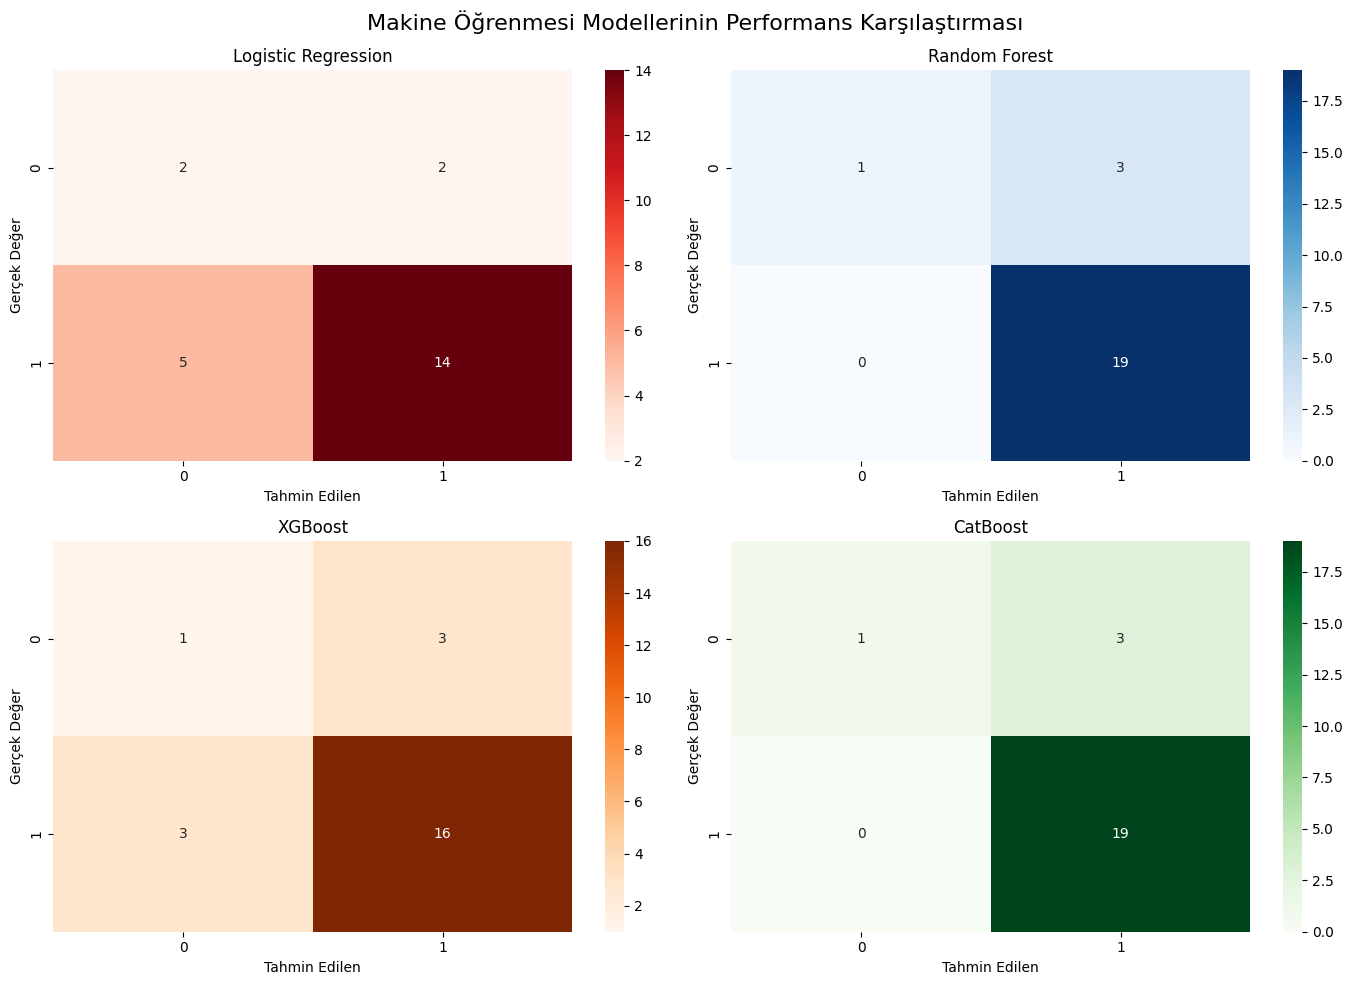

In [25]:
# plt.subplots(2, 2): Aynı pencere içinde 2 satır 2 sütun olmak üzere 4'lü bir ızgara oluşturur.
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle('Makine Öğrenmesi Modellerinin Performans Karşılaştırması', fontsize=16)

# 1. Lojistik Regresyon
sns.heatmap(confusion_matrix(y_test, log_pred), annot=True, fmt='d', cmap='Reds', ax=axes[0, 0])
axes[0, 0].set_title('Logistic Regression')
axes[0, 0].set_xlabel('Tahmin Edilen')
axes[0, 0].set_ylabel('Gerçek Değer')

# 2. Random Forest
sns.heatmap(confusion_matrix(y_test, y_pred), annot=True, fmt='d', cmap='Blues', ax=axes[0, 1])
axes[0, 1].set_title('Random Forest')
axes[0, 1].set_xlabel('Tahmin Edilen')
axes[0, 1].set_ylabel('Gerçek Değer')

# 3. XGBoost
sns.heatmap(confusion_matrix(y_test, xgb_pred), annot=True, fmt='d', cmap='Oranges', ax=axes[1, 0])
axes[1, 0].set_title('XGBoost')
axes[1, 0].set_xlabel('Tahmin Edilen')
axes[1, 0].set_ylabel('Gerçek Değer')

# 4. CatBoost
sns.heatmap(confusion_matrix(y_test, cat_pred), annot=True, fmt='d', cmap='Greens', ax=axes[1, 1])
axes[1, 1].set_title('CatBoost')
axes[1, 1].set_xlabel('Tahmin Edilen')
axes[1, 1].set_ylabel('Gerçek Değer')

plt.tight_layout()
plt.subplots_adjust(top=0.92)
plt.show()